# Mean hitting time for GBT



<p style="color: #7acbd6;">Statement of the problem:</p> A "glued binary tree" of depth N consists of two standard binary trees of depth N/2 joined at their end nodes. The quantity of interest is the mean hitting time (expected time) between node i to j: 

$$
\tau_{ij} = \sum_{t = 0}^{\infty} t\, p_{j}(t)
$$

$p_{j}(t)$: Probability of hitting node j at time t.

<div align="center">
    <img src="binary_ink.png" width="400">
</div>

In order to get a basic understanding of the problem, a diagram is presented of the GBT case when N = 6. It is assumed the probability of moving to a contiguous node is the same for all nodes. $\\$
In the left part of the tree, the probability of travelling towards the middle of the tree is 2/3 and moving backwards is 1/3. In the right part, the probability is shifted, while in the middle there are equal chances of moving to either side.  $\\$
Therefore, in the GBT the odds are skewed towards the middle of the graph. Generalizing we have:

$$
\begin{align}
    &k < \frac{N}{2}: P_{k, k + 1} = \frac{2}{3}; \hspace{10px} P_{k, k - 1} = \frac{1}{3} \\
    &k > \frac{N}{2}: P_{k, k + 1} = \frac{1}{3}; \hspace{10px} P_{k, k - 1} = \frac{2}{3} \\
    &k = \frac{N}{2}: P_{k, k + 1} = P_{k, k - 1} = \frac{1}{2}

\end{align}
$$

For the deduction of the hitting time between opposite nodes, we are going to find a recursive relation. For simplification, the time needed to jump between contiguous nodes is defined as 1.$\\$

### 1. Definition and Basic Relations
We define $\mathcal{T}_k$ as the expected time to reach node $N$ starting from node $k$.
We define the time difference between consecutive steps as:
$$\Delta \tau_k = \mathcal{T}_k - \mathcal{T}_{k+1}$$

The total time to reach $N$ from $0$ is the sum of these increments:
$$\mathcal{T}_0 = \sum_{k=0}^{N-1} \Delta \tau_k$$

The hitting time $\mathcal{T}_k$ at depth $k$ can be calculated as the time required to jump (1 for our purpose) plus the mean hitting of the landing node weighted by the propbability of jumping to that node:
$$\mathcal{T}_k = \mathcal{T}_{k-1} P_{k,k-1} + \mathcal{T}_{k+1} P_{k,k+1} + 1$$

### 2. Recurrence Equations per Section

- Base case: Initial node ($k=0$). $\\$
Since from node $0$ one can only move forward to node $1$ with probability $1$:
$$\mathcal{T}_0 = \mathcal{T}_1 + 1 \implies \mathcal{T}_0 - \mathcal{T}_1 = 1$$
$$\Delta \tau_0 = 1$$

#### B. First half of tree ($0 < k < N/2$)
The probability of moving forward is $2/3$ and moving backward is $1/3$:
$$\mathcal{T}_k = \frac{1}{3}\mathcal{T}_{k-1} + \frac{2}{3}\mathcal{T}_{k+1} + 1$$
We verify that we can write $\mathcal{T}_{k} = \frac{1}{3}\mathcal{T}_k + \frac{2}{3}\mathcal{T}_{k}$, substituting:
$$0 = \frac{1}{3}\Delta \tau_{k-1} - \frac{2}{3}\Delta \tau_k + 1 \implies \Delta \tau_k = \frac{1}{2}\Delta \tau_{k-1} + \frac{3}{2}$$
Solving the recurrence with the base case $\Delta \tau_0 = 1$:
$$\Delta \tau_k - 3 = \frac{1}{2}(\Delta \tau_{k-1} - 3) \implies \Delta \tau_k - 3 = \left(\frac{1}{2}\right)^k (\Delta \tau_0 - 3) = \left(\frac{1}{2}\right)^k (1 - 3)$$
$$\Delta \tau_k = 3 - 2^{1-k}$$

#### C. Midpoint ($k = N/2$)
Here the probabilities are symmetric ($1/2$):
$$\mathcal{T}_{N/2} = \frac{1}{2}\mathcal{T}_{N/2-1} + \frac{1}{2}\mathcal{T}_{N/2+1} + 1 \implies \Delta \tau_{N/2} = \Delta \tau_{N/2-1} + 2$$
Using the previous formula for $\Delta \tau_{N/2-1}$:
$$\Delta \tau_{N/2} = (3 - 2^{1-(N/2-1)}) + 2 = 5 - 2^{2-N/2}$$

#### D. Second half ($N/2 < k < N$)
The probability of moving forward is $1/3$ and moving backward is $2/3$:
$$\mathcal{T}_k = \frac{2}{3}\mathcal{T}_{k-1} + \frac{1}{3}\mathcal{T}_{k+1} + 1 \implies \Delta \tau_k = 2\Delta \tau_{k-1} + 3$$
Applying an equivalent procedure for the recurrence as before, we add 3 to both sides:
$$\Delta \tau_{k} + 3 = 2 (\Delta \tau_{k-1} + 3)$$

Solving the recurrence from the midpoint ($j = k - N/2$):
$$\Delta \tau_{N/2+j} + 3 = 2^j (\Delta \tau_{N/2} + 3)$$
Making use of the precious section, we substitute $\Delta \tau_{N/2}$:
$$\Delta \tau_{N/2+j} = 2^j (8 - 2^{2-N/2}) - 3 = 2^{j+3} - 2^{j+2-N/2} - 3$$

### 3. Final Summation
We sum all sections to obtain $\mathcal{T}_0$:

1.  **Sum from $k=0$ to $N/2-1$:**
    $$\sum_{k=0}^{N/2-1} (3 - 2^{1-k}) = \frac{3N}{2} - 4 + 2^{2-N/2}$$

2.  **Midpoint $\Delta \tau_{N/2}$:**
    $$5 - 2^{2-N/2}$$

3.  **Sum from $k=N/2+1$ to $N-1$ (using $j=1$ to $N/2-1$):**
    $$\sum_{j=1}^{N/2-1} (2^{j+3} - 2^{j+2-N/2} - 3) = 2^{N/2+3} + 2^{3-N/2} - \frac{3N}{2} - 17$$

**Total:**
$$\mathcal{T}_0 = \left( \frac{3N}{2} - 4 + 2^{2-N/2} \right) + \left( 5 - 2^{2-N/2} \right) + \left( 2^{N/2+3} + 2^{3-N/2} - \frac{3N}{2} - 17 \right)$$

Simplifying the linear $N$ terms and the constants:
$$\mathcal{T}_0 = 2^{N/2+3} + 2^{3-N/2} - 16$$

Or in terms of hyperbolic functions:
$$\mathcal{T}_0 = 16 \left( \cosh\left[ \frac{N}{2} \ln(2) \right] - 1 \right)$$

This results denotes the mean time should grow cuadratically for N values very close to 0, and exponentially (base 2), for values N>>1. In the following, a numerical simulation will validate the results obtained theoretically.

## NUMERICAL SIMULATION



In [ ]:
import numpy as np
from numba import njit, prange
import time


@njit(parallel=True)
def binary_tree_sim(depth, num_simulations, start_node, end_node):
    middle_depth = depth // 2
    first_half_node = 2**middle_depth
    last_half_node = (2**(middle_depth + 1) - 1)
    total_nodes = 2**(middle_depth + 1) + 2**middle_depth - 2
    c_inferior = 3 * 2**(middle_depth - 1)

    if end_node == "End":
        end_node = total_nodes

    mean_time_array = np.empty(num_simulations, dtype=np.int32)

    for i in prange(num_simulations):
        node = start_node
        tiempo = 0

        while node != end_node:
            if node == 1:
                if np.random.randint(2) == 0:
                    node = 2
                else:
                    node = 3

            elif node < first_half_node:
                r = np.random.randint(3)
                if r == 0:
                    node = node // 2
                elif r == 1:
                    node = 2 * node
                else:
                    node = 2 * node + 1

            elif node <= last_half_node:
                if np.random.randint(2) == 0:
                    node = node // 2
                else:
                    node = node // 2 + c_inferior

            else:
                r = np.random.randint(3)
                if r == 0:
                    node = node // 2 + c_inferior
                elif r == 1:
                    node = 2 * (node - c_inferior)
                else:
                    node = 2 * (node - c_inferior) + 1
                    
            tiempo += 1
        mean_time_array[i] = tiempo
    return mean_time_array




depth = 12
n_simulaciones = 10000000

print(f"Ejecutando {n_simulaciones} simulaciones a máxima velocidad...")
inicio = time.time()

resultados = binary_tree_sim(depth, n_simulaciones, 0, "end")

fin = time.time()
print(f"Simulaciones terminadas en {fin - inicio:.2f} segundos.")

np.savetxt("mean_time_array.txt", resultados, fmt='%d', newline=' ')
print("Datos guardados en 'mean_time_array.txt'.")

Aquí la ejecución para vertices opuestos

In [ ]:
tree = binary_tree(14)
with open("hitting_times.txt", "w") as f:
    for num_simulations in range(0, 10000):
        tree.set_extreme_points(1, tree.total_nodes)
        while (not tree.finish):
            tree.random_step()
    
        f.write(f"{int(tree.total_time)} ")

COdigo para visualizarlo:

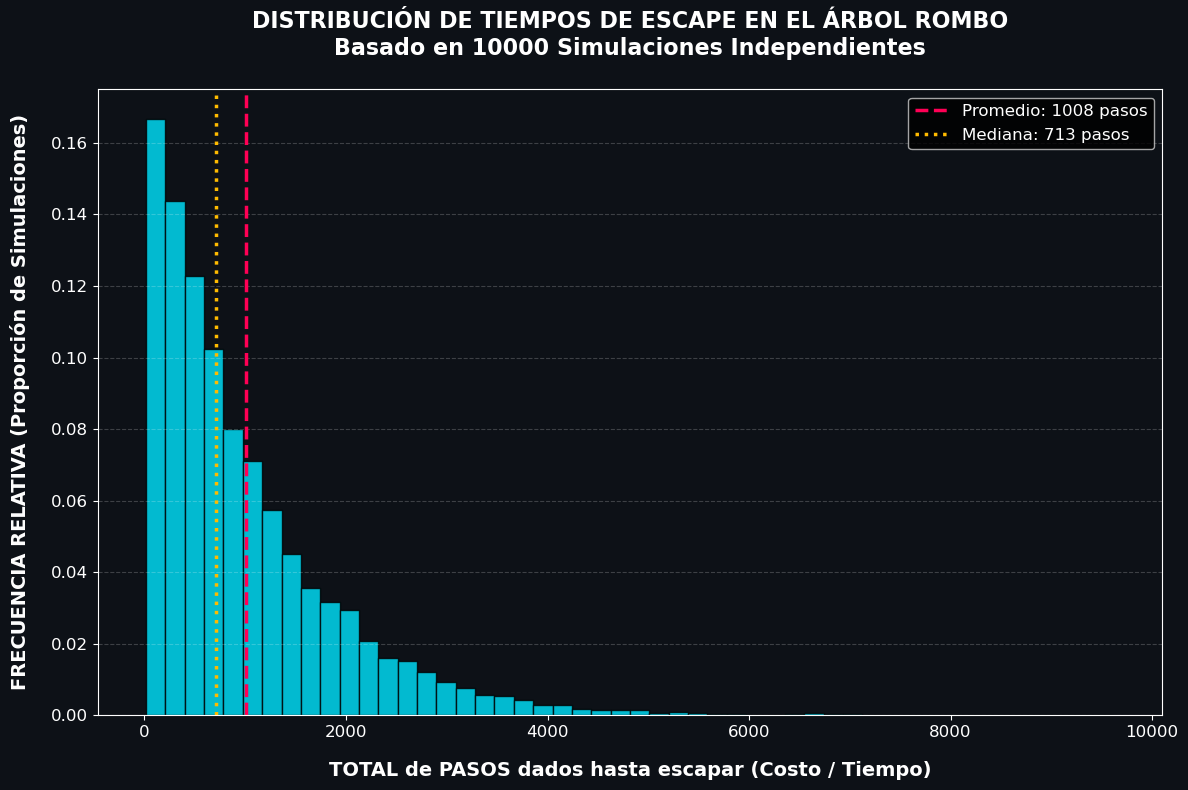

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LEER LOS DATOS (HIT PASADO)
# ==========================================
# Nombre del archivo donde están tus tiempos de escape
nombre_archivo = "hitting_times.txt"

try:
    with open(nombre_archivo, "r") as archivo:
        # Leemos el texto, lo limpiamos de flotantes accidentales y creamos la lista de enteros
        tiempos_de_escape = [int(float(x)) for x in archivo.read().split()]
except FileNotFoundError:
    print(f"Error Crítico: No se encontró el archivo '{nombre_archivo}'.")
    print("Asegúrate de ejecutar primero 'simulacion.py' para generar los datos.")
    exit()

if not tiempos_de_escape:
    print(f"Error: El archivo '{nombre_archivo}' está vacío.")
    exit()

# ==========================================
# 2. CALCULAR ESTADÍSTICAS
# ==========================================
total_intentos = len(tiempos_de_escape)
promedio = np.mean(tiempos_de_escape)
mediana = np.median(tiempos_de_escape)

# ==========================================
# 3. DIBUJAR EL HISTOGRAMA (VISUALIZACIÓN CLARA)
# ==========================================
# Creamos una figura más grande para mayor comodidad
fig, ax = plt.subplots(figsize=(12, 8))

# Activamos el modo oscuro para el estilo 'Cian/Magenta' neón
plt.style.use('dark_background')

# Configuramos el color de fondo de la figura y del eje
fig.patch.set_facecolor('#0d1117') 
ax.set_facecolor('#0d1117')

# --- MODIFICACIÓN AQUÍ: Calculamos los pesos para obtener frecuencia relativa ---
pesos = np.ones_like(tiempos_de_escape) / total_intentos

# Dibujamos el histograma usando los pesos
plt.hist(tiempos_de_escape, bins=50, weights=pesos, color='#00e5ff', edgecolor='black', alpha=0.8)

# Dibujamos las líneas de referencia estadísticas
plt.axvline(promedio, color='#ff0055', linestyle='dashed', linewidth=2.5, 
            label=f'Promedio: {promedio:.0f} pasos')
plt.axvline(mediana, color='#ffbb00', linestyle='dotted', linewidth=2.5, 
            label=f'Mediana: {mediana:.0f} pasos')

# ------------------------------------------
# --- AQUÍ ESTÁ LA CLARIDAD DE EJES ---
# ------------------------------------------

# TÍTULO PRINCIPAL GRANDE Y CLARO
plt.title(f'DISTRIBUCIÓN DE TIEMPOS DE ESCAPE EN EL ÁRBOL ROMBO\nBasado en {total_intentos} Simulaciones Independientes', 
          fontsize=16, fontweight='bold', color='white', pad=25)

# EJE X (Horizontal): TOTAL DE PASOS
plt.xlabel('TOTAL de PASOS dados hasta escapar (Costo / Tiempo)', 
           fontsize=14, fontweight='bold', color='white', labelpad=15)

# --- MODIFICACIÓN AQUÍ: Actualizamos la etiqueta del eje Y ---
# EJE Y (Vertical): FRECUENCIA RELATIVA
plt.ylabel('FRECUENCIA RELATIVA (Proporción de Simulaciones)', 
           fontsize=14, fontweight='bold', color='white', labelpad=15)

# LEYENDA (Mean/Median) MÁS GRANDE
plt.legend(fontsize=12)

# Aumentamos el tamaño de los números de los ejes X e Y
plt.tick_params(axis='both', which='major', labelsize=12, labelcolor='white')

# AÑADIMOS UNA CUADRÍCULA SUTIL (Aplica a todo el fondo)
plt.grid(True, axis='y', alpha=0.2, linestyle='--', color='white')

# Ajustamos para que nada se corte
plt.tight_layout()

# Mostramos el resultado
plt.show()